# Import Libraries

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import time
from IPython.display import display

# Suppress warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

print("=" * 80)
print("AIRLINE PASSENGER SATISFACTION PREDICTION")
print("Classification Project: Multi-Algorithm Comparison")
print("=" * 80)

AIRLINE PASSENGER SATISFACTION PREDICTION
Classification Project: Multi-Algorithm Comparison


# Mount Google Drive and Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/airline_passenger_satisfaction.csv")
print(f"✓ Dataset loaded successfully: {df.shape[0]:,} rows × {df.shape[1]} columns")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Dataset loaded successfully: 129,880 rows × 24 columns


# CELL 3: Initial Data Assessment


In [ ]:
print("INITIAL DATA ASSESSMENT")

print("\n[3.1] First 5 Rows:")
display(df.head())


INITIAL DATA ASSESSMENT

[3.1] First 5 Rows:


,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


In [ ]:
print("\n[3.2] Random Sample (5 rows):")
display(df.sample(5, random_state=42))


[3.2] Random Sample (5 rows):


,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
103044,103045,Male,23,First-time,Business,Economy,546,0,0.0,4,...,3,2,1,2,2,3,3,2,4,Neutral or Dissatisfied
43282,43283,Male,38,Returning,Business,Economy,531,0,0.0,1,...,2,5,2,5,5,3,5,5,1,Satisfied
65543,65544,Male,33,Returning,Business,Business,237,0,3.0,3,...,3,4,4,4,4,5,3,4,4,Satisfied
65083,65084,Male,68,Returning,Personal,Economy,224,0,0.0,3,...,2,1,2,1,1,5,4,1,3,Satisfied
76496,76497,Male,27,First-time,Business,Business,516,7,0.0,5,...,4,1,3,4,4,5,5,4,4,Satisfied


In [ ]:
print("\n[3.3] Last 5 Rows:")
display(df.tail())


[3.3] Last 5 Rows:


,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
129875,129876,Male,28,Returning,Personal,Economy Plus,447,2,3.0,4,...,5,1,4,4,4,5,4,4,4,Neutral or Dissatisfied
129876,129877,Male,41,Returning,Personal,Economy Plus,308,0,0.0,5,...,5,2,5,2,2,4,3,2,5,Neutral or Dissatisfied
129877,129878,Male,42,Returning,Personal,Economy Plus,337,6,14.0,5,...,3,3,4,3,3,4,2,3,5,Neutral or Dissatisfied
129878,129879,Male,50,Returning,Personal,Economy Plus,337,31,22.0,4,...,4,4,5,3,3,4,5,3,5,Satisfied
129879,129880,Female,20,Returning,Personal,Economy Plus,337,0,0.0,1,...,4,2,4,2,2,2,3,2,1,Neutral or Dissatisfied


In [ ]:
print("\n[3.4] Dataset Information:")
print(df.info())


[3.4] Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  int64  
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online B

In [ ]:
print("\n[3.5] Missing Values Check:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found!")
else:
    print(missing[missing > 0])


[3.5] Missing Values Check:
Arrival Delay    393
dtype: int64


In [ ]:
print("\n[3.6] Duplicate Rows Check:")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates:,}")


[3.6] Duplicate Rows Check:
Number of duplicate rows: 0


In [ ]:
print("\n[3.7] Descriptive Statistics:")
display(df.describe())


[3.7] Descriptive Statistics:


,ID,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,64940.500000,39.427957,1190.316392,14.713713,15.091129,3.057599,2.756876,3.306267,3.252633,2.976925,3.383023,3.441361,3.350878,3.286326,3.204774,3.642193,2.728696,3.358077,3.632114
std,37493.270818,15.119360,997.452477,38.071126,38.465650,1.526741,1.401740,1.266185,1.350719,1.278520,1.287099,1.319289,1.316252,1.313682,1.329933,1.176669,1.329340,1.334049,1.180025
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,32470.750000,27.000000,414.000000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,64940.500000,40.000000,844.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,97410.250000,51.000000,1744.000000,12.000000,13.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,129880.000000,85.000000,4983.000000,1592.000000,1584.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


# CELL 4: Data Cleaning


In [ ]:
print("\n" + "=" * 80)
print("DATA CLEANING")
print("=" * 80)

# Create a copy for cleaning
df_clean = df.copy()

# Remove duplicates
print("\n[4.1] Removing Duplicates...")
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"✓ Removed {before - after:,} duplicate rows")

# Handle missing values
print("\n[4.2] Handling Missing Values...")
if 'Arrival Delay' in df_clean.columns:
    missing_delay = df_clean['Arrival Delay'].isnull().sum()
    if missing_delay > 0:
        median_delay = df_clean['Arrival Delay'].median()
        df_clean['Arrival Delay'].fillna(median_delay, inplace=True)
        print(f"✓ Filled {missing_delay:,} missing values in 'Arrival Delay' with median: {median_delay:.1f}")
    else:
        print("✓ No missing values in 'Arrival Delay'")

# Clean column names
print("\n[4.3] Standardizing Column Names...")
rename_map = {
    'Customer Type': 'customer_type',
    'Type of Travel': 'type_of_travel',
    'Flight Distance': 'flight_distance',
    'Departure Delay': 'departure_delay',
    'Arrival Delay': 'arrival_delay',
    'Satisfaction': 'satisfaction'
}

for old_name, new_name in rename_map.items():
    if old_name in df_clean.columns:
        df_clean.rename(columns={old_name: new_name}, inplace=True)

df_clean.columns = df_clean.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')

print("✓ Column names standardized to snake_case")
print("\nCleaned columns:")
print(df_clean.columns.tolist())


DATA CLEANING

[4.1] Removing Duplicates...
✓ Removed 0 duplicate rows

[4.2] Handling Missing Values...
✓ Filled 393 missing values in 'Arrival Delay' with median: 0.0

[4.3] Standardizing Column Names...
✓ Column names standardized to snake_case

Cleaned columns:
['id', 'gender', 'age', 'customer_type', 'type_of_travel', 'class', 'flight_distance', 'departure_delay', 'arrival_delay', 'departure_and_arrival_time_convenience', 'ease_of_online_booking', 'check_in_service', 'online_boarding', 'gate_location', 'on_board_service', 'seat_comfort', 'leg_room_service', 'cleanliness', 'food_and_drink', 'in_flight_service', 'in_flight_wifi_service', 'in_flight_entertainment', 'baggage_handling', 'satisfaction']


# CELL 5: Outlier Detection And Treatment

In [ ]:
print("\n" + "=" * 80)
print("OUTLIER DETECTION & TREATMENT")
print("=" * 80)

def cap_outliers_iqr(data, column):
    """Cap outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_before = ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()

    data[column] = np.where(
        data[column] < lower_bound, lower_bound,
        np.where(data[column] > upper_bound, upper_bound, data[column])
    )

    return lower_bound, upper_bound, outliers_before

print("\n[5.1] Detecting and Capping Outliers...")

outlier_features = ['flight_distance', 'departure_delay', 'arrival_delay']
outlier_summary = []

for col in outlier_features:
    if col in df_clean.columns:
        lb, ub, count = cap_outliers_iqr(df_clean, col)
        outlier_summary.append({
            'Feature': col,
            'Lower Bound': lb,
            'Upper Bound': ub,
            'Outliers Capped': count,
            'Percentage': f"{(count/len(df_clean)*100):.2f}%"
        })
        print(f"✓ {col}: capped to [{lb:.1f}, {ub:.1f}] | Outliers: {count} ({(count/len(df_clean)*100):.2f}%)")

outlier_df = pd.DataFrame(outlier_summary)


OUTLIER DETECTION & TREATMENT

[5.1] Detecting and Capping Outliers...
✓ flight_distance: capped to [-1581.0, 3739.0] | Outliers: 2855 (2.20%)
✓ departure_delay: capped to [-18.0, 30.0] | Outliers: 18098 (13.93%)
✓ arrival_delay: capped to [-19.5, 32.5] | Outliers: 17492 (13.47%)



OUTLIER TREATMENT VISUALIZATION


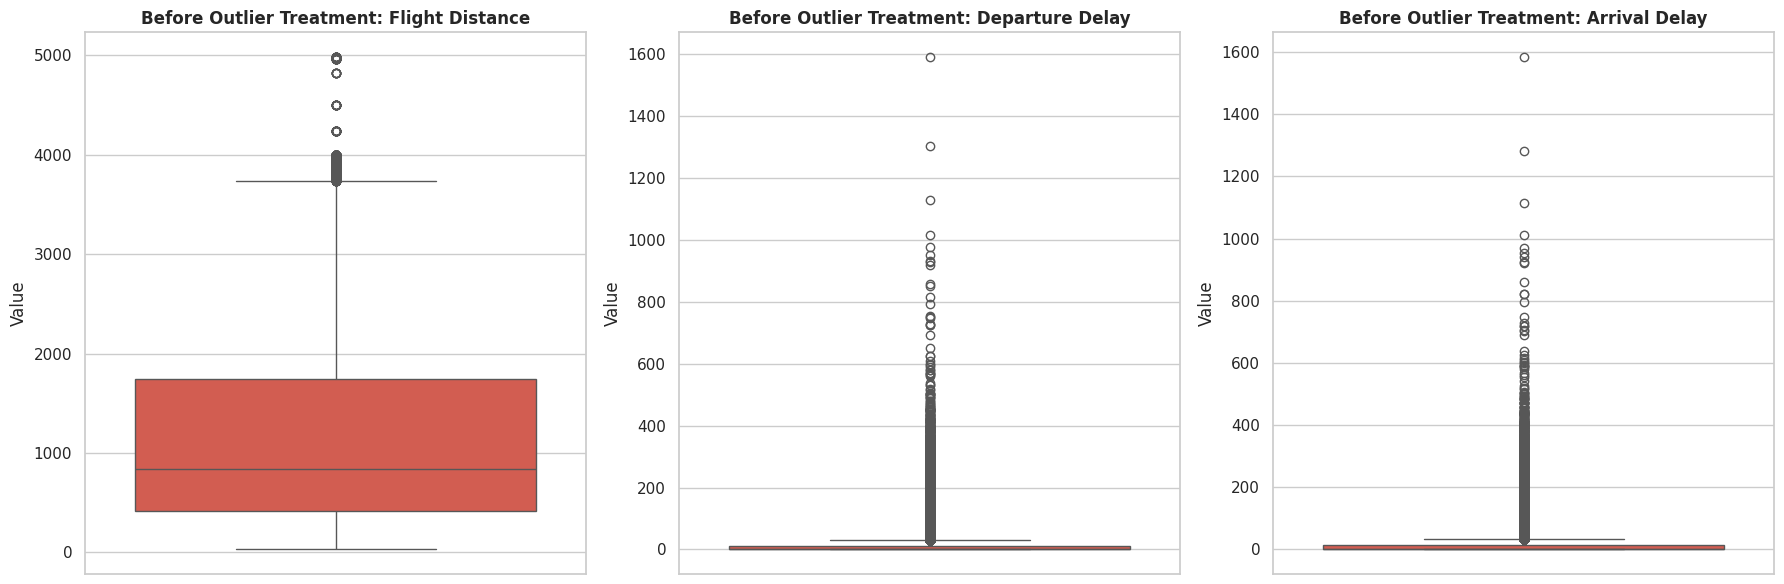

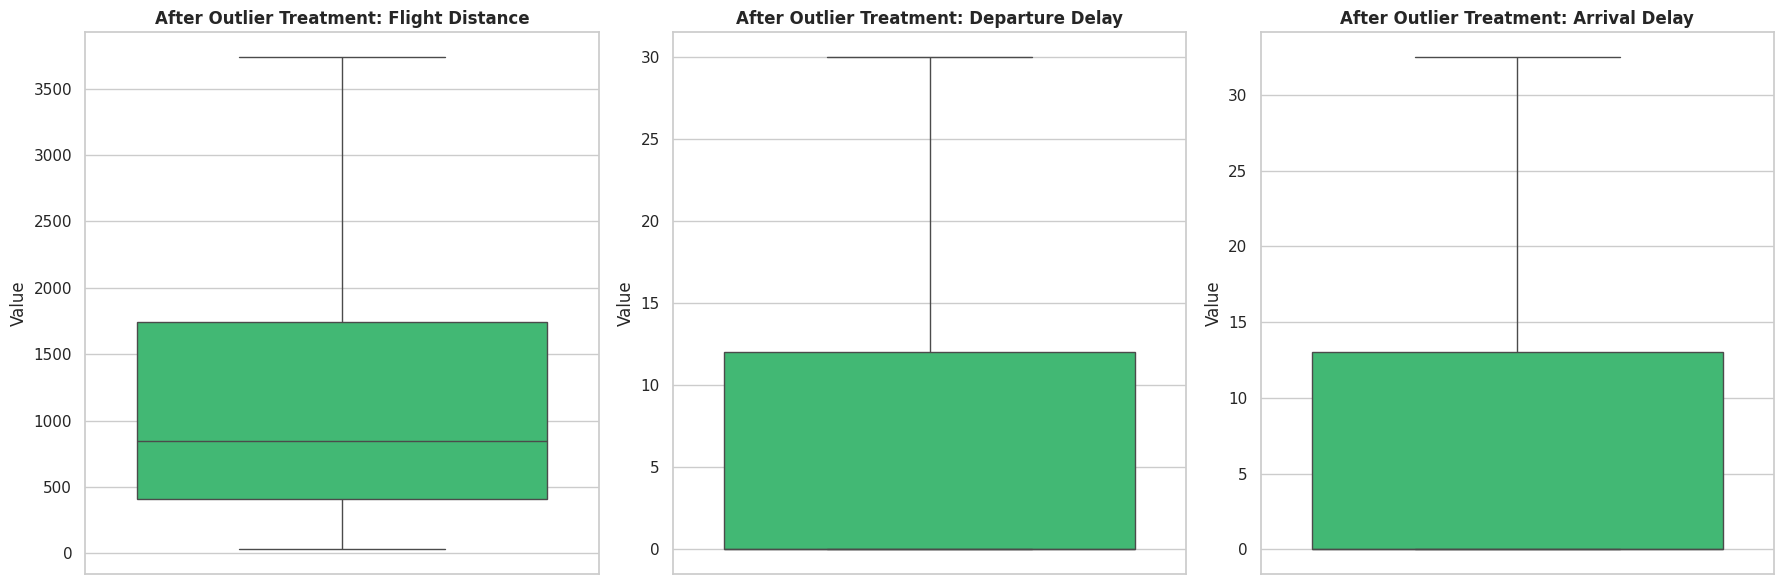

In [ ]:
# ============================================================================
# CELL 5.1: VISUALIZE BEFORE & AFTER OUTLIER TREATMENT
# ============================================================================

print("\n" + "=" * 80)
print("OUTLIER TREATMENT VISUALIZATION")
print("=" * 80)

# Reload original data for comparison
df_before = pd.read_csv("/content/drive/MyDrive/airline_passenger_satisfaction.csv")
df_before = df_before.drop_duplicates()
df_before.columns = df_before.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')
if 'arrival_delay' in df_before.columns:
    df_before['arrival_delay'].fillna(df_before['arrival_delay'].median(), inplace=True)

# Features to compare
features = ['flight_distance', 'departure_delay', 'arrival_delay']

# BEFORE: Box plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, col in enumerate(features):
    sns.boxplot(y=df_before[col], ax=axes[idx], color='#e74c3c')
    axes[idx].set_title(f'Before Outlier Treatment: {col.replace("_", " ").title()}',
                        fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Value')
plt.tight_layout()
plt.show()

# AFTER: Box plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, col in enumerate(features):
    sns.boxplot(y=df_clean[col], ax=axes[idx], color='#2ecc71')
    axes[idx].set_title(f'After Outlier Treatment: {col.replace("_", " ").title()}',
                        fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Value')
plt.tight_layout()
plt.show()

In [ ]:
# COMPARISON TABLE
comparison = pd.DataFrame({
    'Before_Mean': df_before[features].mean(),
    'After_Mean': df_clean[features].mean(),
    'Before_Std': df_before[features].std(),
    'After_Std': df_clean[features].std(),
    'Before_Max': df_before[features].max(),
    'After_Max': df_clean[features].max()
})

print("\n" + "=" * 80)
print("OUTLIER TREATMENT COMPARISON")
print("=" * 80)
display(comparison)

print("\n✓ Outlier treatment visualization complete")


OUTLIER TREATMENT COMPARISON


,Before_Mean,After_Mean,Before_Std,After_Std,Before_Max,After_Max
flight_distance,1190.316392,1186.995681,997.452477,988.394696,4983.0,3739.0
departure_delay,14.713713,7.380798,38.071126,11.209935,1592.0,30.0
arrival_delay,15.045465,7.909386,38.416353,11.971151,1584.0,32.5



✓ Outlier treatment visualization complete


# CELL 6: Feature Engineering

In [ ]:
print("\n" + "=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)

print("\n[6.1] Creating New Features...")

# Total Delay
if 'departure_delay' in df_clean.columns and 'arrival_delay' in df_clean.columns:
    df_clean['total_delay'] = df_clean['departure_delay'] + df_clean['arrival_delay']
    print("✓ Created 'total_delay' = departure_delay + arrival_delay")

# Service Score Average
service_cols = [col for col in df_clean.columns if any(x in col.lower() for x in
                ['seat', 'food', 'entertainment', 'wifi', 'boarding', 'service', 'cleanliness'])]

if len(service_cols) > 0:
    df_clean['avg_service_score'] = df_clean[service_cols].mean(axis=1)
    print(f"✓ Created 'avg_service_score' from {len(service_cols)} service ratings")

# Delay severity categories
if 'total_delay' in df_clean.columns:
    df_clean['delay_category'] = pd.cut(
        df_clean['total_delay'],
        bins=[-np.inf, 0, 15, 60, np.inf],
        labels=['No Delay', 'Minor', 'Moderate', 'Severe']
    )
    print("✓ Created 'delay_category' (No Delay, Minor, Moderate, Severe)")

print(f"\n✓ Total features after engineering: {df_clean.shape[1]}")


FEATURE ENGINEERING

[6.1] Creating New Features...
✓ Created 'total_delay' = departure_delay + arrival_delay
✓ Created 'avg_service_score' from 10 service ratings
✓ Created 'delay_category' (No Delay, Minor, Moderate, Severe)

✓ Total features after engineering: 27


# CELL 7: Define EDA Functions

In [ ]:
def univariate_analysis_numerical(df, column, bins=30):
    """Perform univariate analysis on numerical column"""
    print(f"\n{'='*60}")
    print(f"Analysis for: {column}")
    print('='*60)

    print("\nSummary Statistics:")
    print(df[column].describe())
    print(f"\nSkewness: {df[column].skew():.3f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Histogram
    df[column].plot(kind='hist', bins=bins, ax=axes[0], edgecolor='black', color='steelblue')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'Histogram of {column}')
    axes[0].grid(alpha=0.3)

    # KDE
    df[column].plot(kind='kde', ax=axes[1], color='darkgreen', linewidth=2)
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Density')
    axes[1].set_title(f'KDE of {column}')
    axes[1].grid(alpha=0.3)

    # Boxplot
    df[column].plot(kind='box', ax=axes[2], color='coral')
    axes[2].set_ylabel('Value')
    axes[2].set_title(f'Box Plot of {column}')
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def univariate_analysis_categorical(df, column, show_pie=True):
    """Perform univariate analysis on categorical column"""
    print(f"\n{'='*60}")
    print(f"Analysis for: {column}")
    print('='*60)

    counts = df[column].value_counts()
    print("\nValue Counts:")
    print(counts)
    print(f"\nMissing Values: {df[column].isnull().sum()}")

    if show_pie:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        counts.plot(kind='bar', ax=axes[0], edgecolor='black', color='teal')
        axes[0].set_xlabel(column)
        axes[0].set_ylabel('Count')
        axes[0].set_title(f'Distribution of {column}')
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].grid(alpha=0.3)

        counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[1], startangle=90)
        axes[1].set_ylabel('')
        axes[1].set_title(f'Proportion of {column}')
    else:
        fig, ax = plt.subplots(figsize=(10, 5))
        counts.plot(kind='bar', ax=ax, edgecolor='black', color='teal')
        ax.set_xlabel(column)
        ax.set_ylabel('Count')
        ax.set_title(f'Distribution of {column}')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def bivariate_categorical_vs_target(df, cat_col, target_col):
    """Analyze categorical feature vs target"""
    print(f"\n{'='*60}")
    print(f"Analysis: {cat_col} vs {target_col}")
    print('='*60)

    crosstab = pd.crosstab(df[cat_col], df[target_col], normalize='index') * 100
    print("\nPercentage Distribution:")
    print(crosstab.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.countplot(data=df, x=cat_col, hue=target_col, ax=axes[0], palette='Set2')
    axes[0].set_title(f'{target_col} by {cat_col}', fontweight='bold')
    axes[0].set_xlabel(cat_col)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(title=target_col)
    axes[0].grid(alpha=0.3)

    crosstab.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
    axes[1].set_title(f'{target_col} % Distribution by {cat_col}', fontweight='bold')
    axes[1].set_xlabel(cat_col)
    axes[1].set_ylabel('Percentage')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title=target_col)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

print("✓ EDA functions defined successfully")

✓ EDA functions defined successfully


# CELL 8: Univariate Analysis - Target Variable



UNIVARIATE ANALYSIS - TARGET VARIABLE

Analysis for: satisfaction

Value Counts:
satisfaction
Neutral or Dissatisfied    73452
Satisfied                  56428
Name: count, dtype: int64

Missing Values: 0


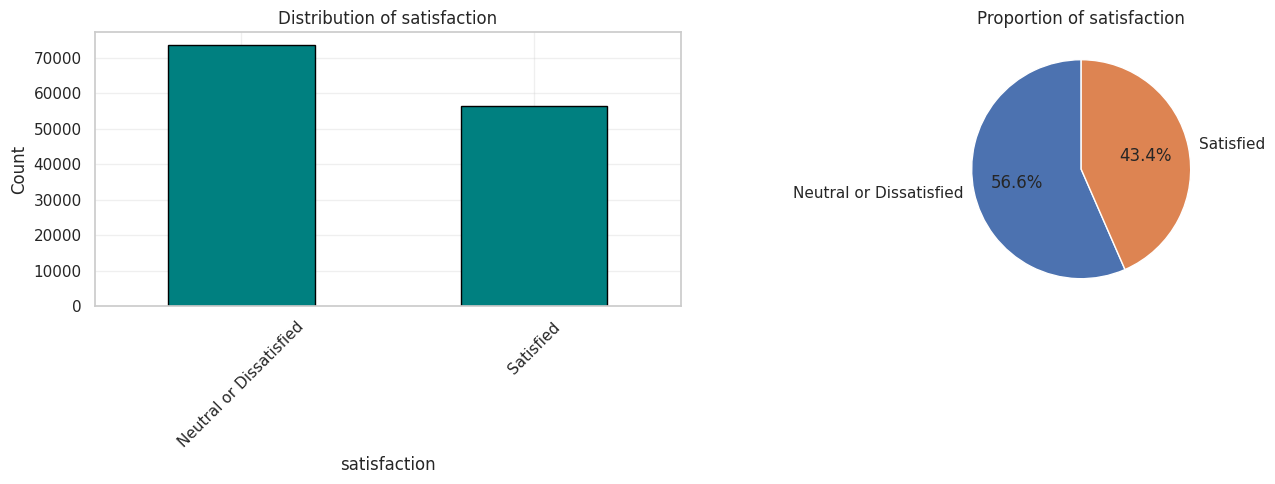


✓ Overall Satisfaction Rate: 43.45%


In [ ]:
print("UNIVARIATE ANALYSIS - TARGET VARIABLE")

if 'satisfaction' in df_clean.columns:
    univariate_analysis_categorical(df_clean, 'satisfaction', show_pie=True)

    if df_clean['satisfaction'].dtype == 'object':
        satisfaction_rate = (df_clean['satisfaction'] == 'Satisfied').mean() * 100
    else:
        satisfaction_rate = df_clean['satisfaction'].mean() * 100
    print(f"\n✓ Overall Satisfaction Rate: {satisfaction_rate:.2f}%")

# CELL 9: Univariate Analysis - Numerical Features



UNIVARIATE ANALYSIS - NUMERICAL FEATURES

Analyzing 20 numerical features...

Analysis for: age

Summary Statistics:
count    129880.000000
mean         39.427957
std          15.119360
min           7.000000
25%          27.000000
50%          40.000000
75%          51.000000
max          85.000000
Name: age, dtype: float64

Skewness: -0.004


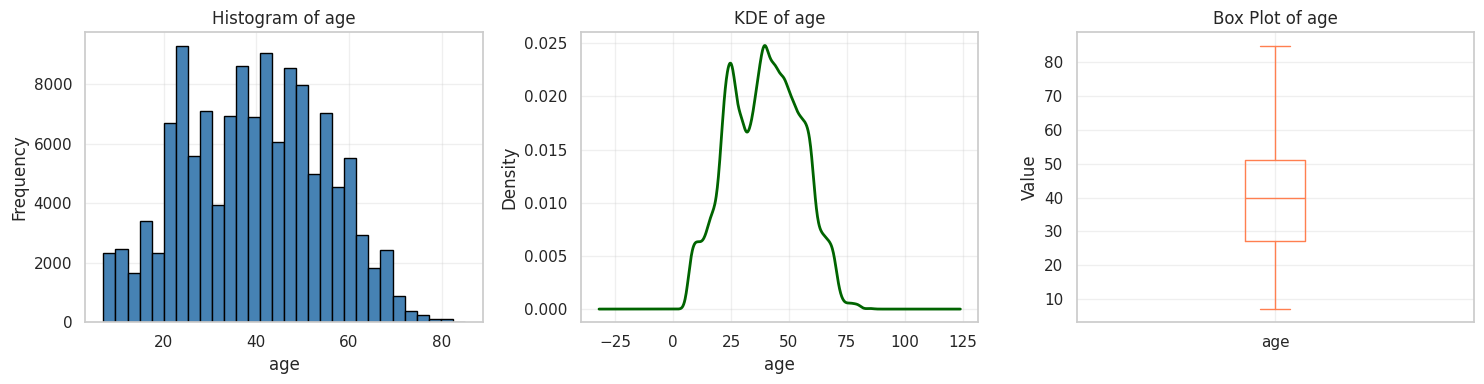


Analysis for: flight_distance

Summary Statistics:
count    129880.000000
mean       1186.995681
std         988.394696
min          31.000000
25%         414.000000
50%         844.000000
75%        1744.000000
max        3739.000000
Name: flight_distance, dtype: float64

Skewness: 1.073


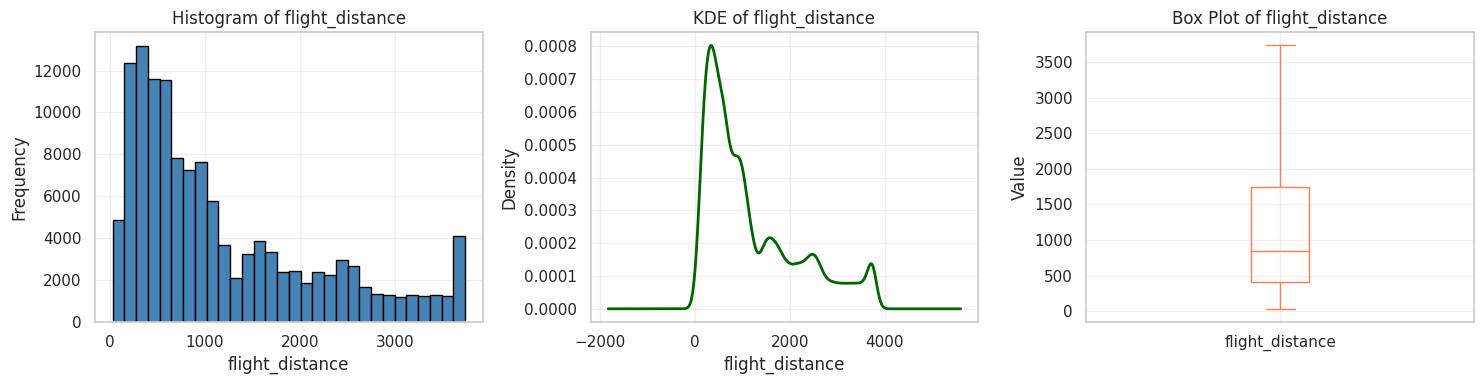


Analysis for: departure_delay

Summary Statistics:
count    129880.000000
mean          7.380798
std          11.209935
min           0.000000
25%           0.000000
50%           0.000000
75%          12.000000
max          30.000000
Name: departure_delay, dtype: float64

Skewness: 1.219


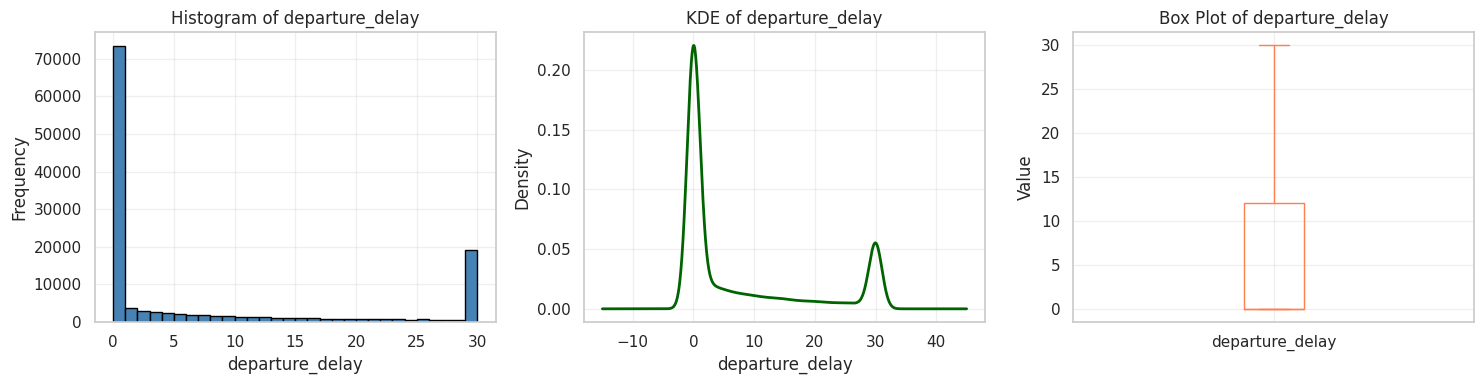


Analysis for: arrival_delay

Summary Statistics:
count    129880.000000
mean          7.909386
std          11.971151
min           0.000000
25%           0.000000
50%           0.000000
75%          13.000000
max          32.500000
Name: arrival_delay, dtype: float64

Skewness: 1.236


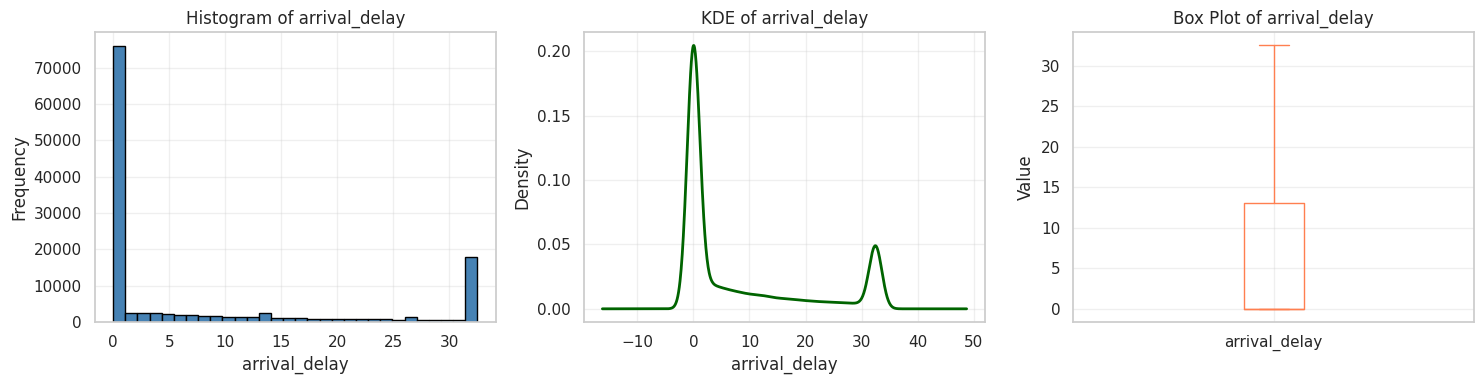


Analysis for: total_delay

Summary Statistics:
count    129880.000000
mean         15.290183
std          22.221579
min           0.000000
25%           0.000000
50%           2.000000
75%          24.000000
max          62.500000
Name: total_delay, dtype: float64

Skewness: 1.261


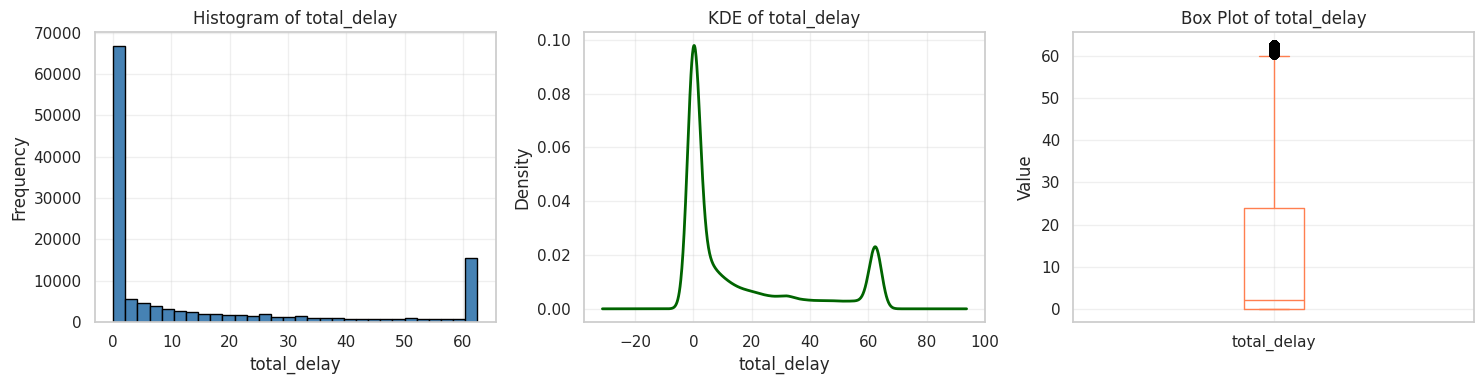

In [ ]:
print("UNIVARIATE ANALYSIS - NUMERICAL FEATURES")

numerical_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numerical_features = [col for col in numerical_features if 'id' not in col.lower()]

print(f"\nAnalyzing {len(numerical_features)} numerical features...")

key_numerical = ['age', 'flight_distance', 'departure_delay', 'arrival_delay', 'total_delay']
key_numerical = [col for col in key_numerical if col in df_clean.columns]

for col in key_numerical[:5]:
    univariate_analysis_numerical(df_clean, col)

# CELL 10: Univariate Analysis - Categorial Features


UNIVARIATE ANALYSIS - CATEGORICAL FEATURES

Analyzing 4 categorical features...

Analysis for: gender

Value Counts:
gender
Female    65899
Male      63981
Name: count, dtype: int64

Missing Values: 0


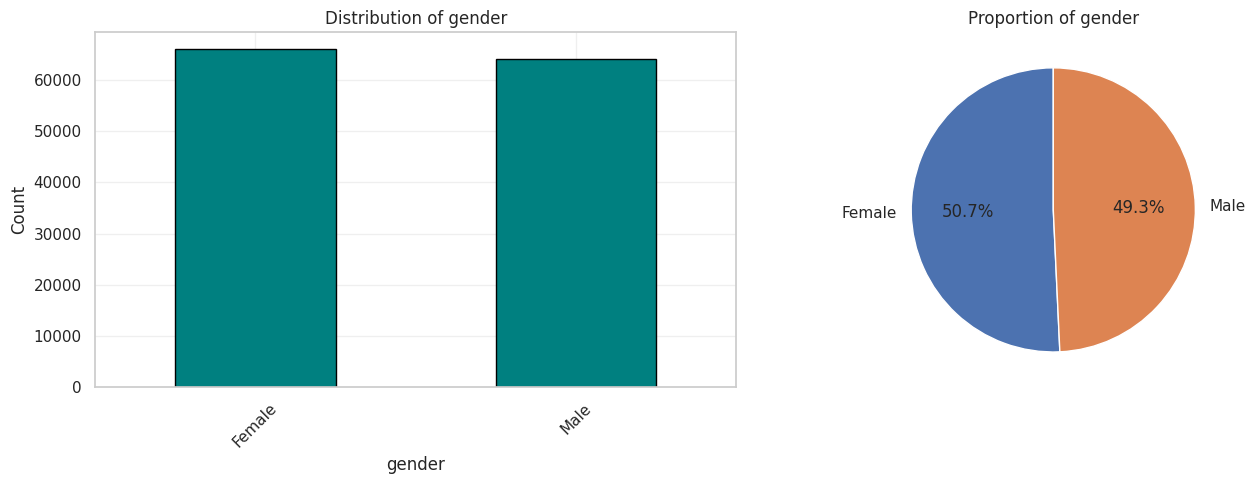


Analysis for: customer_type

Value Counts:
customer_type
Returning     106100
First-time     23780
Name: count, dtype: int64

Missing Values: 0


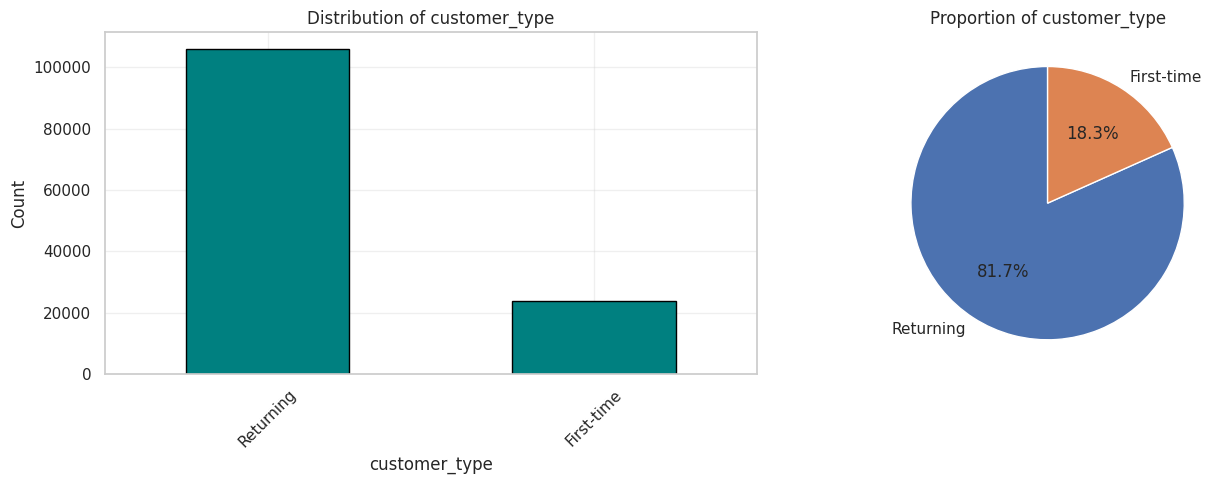


Analysis for: type_of_travel

Value Counts:
type_of_travel
Business    89693
Personal    40187
Name: count, dtype: int64

Missing Values: 0


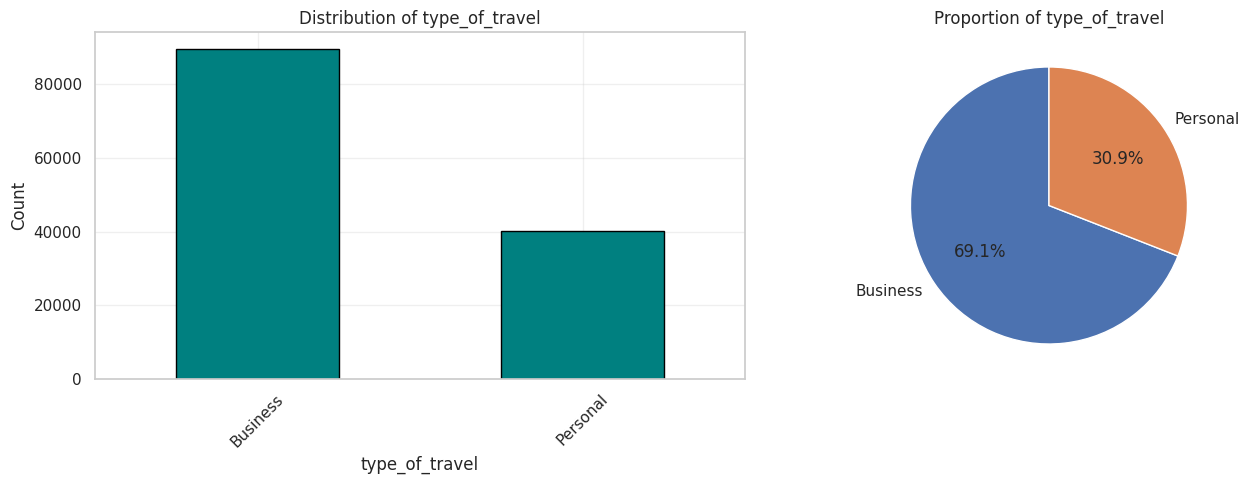


Analysis for: class

Value Counts:
class
Business        62160
Economy         58309
Economy Plus     9411
Name: count, dtype: int64

Missing Values: 0


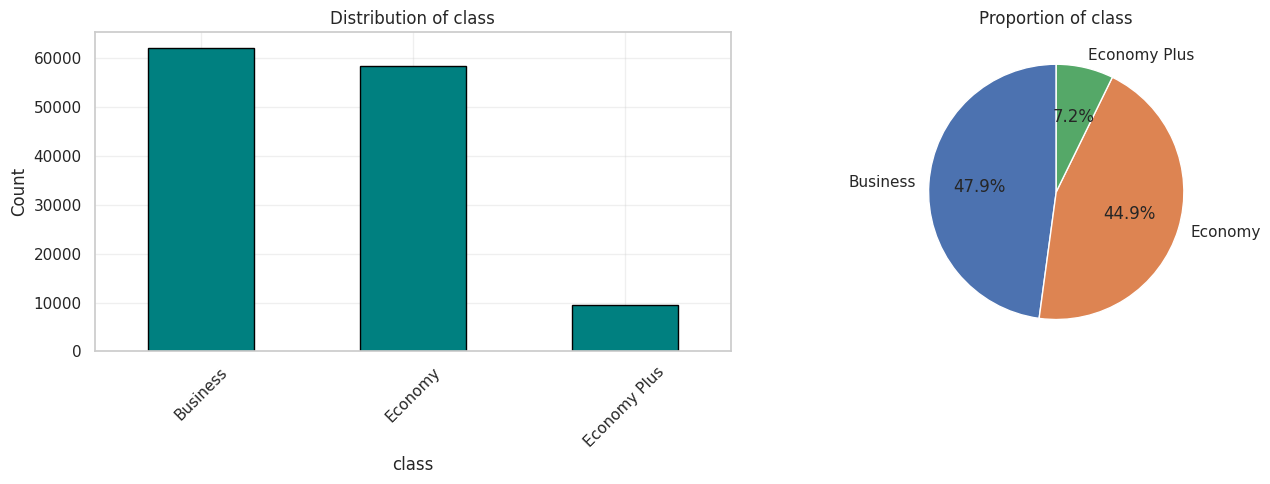

In [ ]:
print("UNIVARIATE ANALYSIS - CATEGORICAL FEATURES")

categorical_features = df_clean.select_dtypes(include=['object']).columns.tolist()
categorical_features = [col for col in categorical_features if col != 'satisfaction']

print(f"\nAnalyzing {len(categorical_features)} categorical features...")

for col in categorical_features[:4]:
    univariate_analysis_categorical(df_clean, col, show_pie=(len(df_clean[col].unique()) <= 4))

# CELL 11: Bivariate Analysis- Categorial VS Target


BIVARIATE ANALYSIS - CATEGORICAL vs TARGET

Analysis: gender vs satisfaction

Percentage Distribution:
satisfaction  Neutral or Dissatisfied  Satisfied
gender                                          
Female                          57.10      42.90
Male                            55.99      44.01


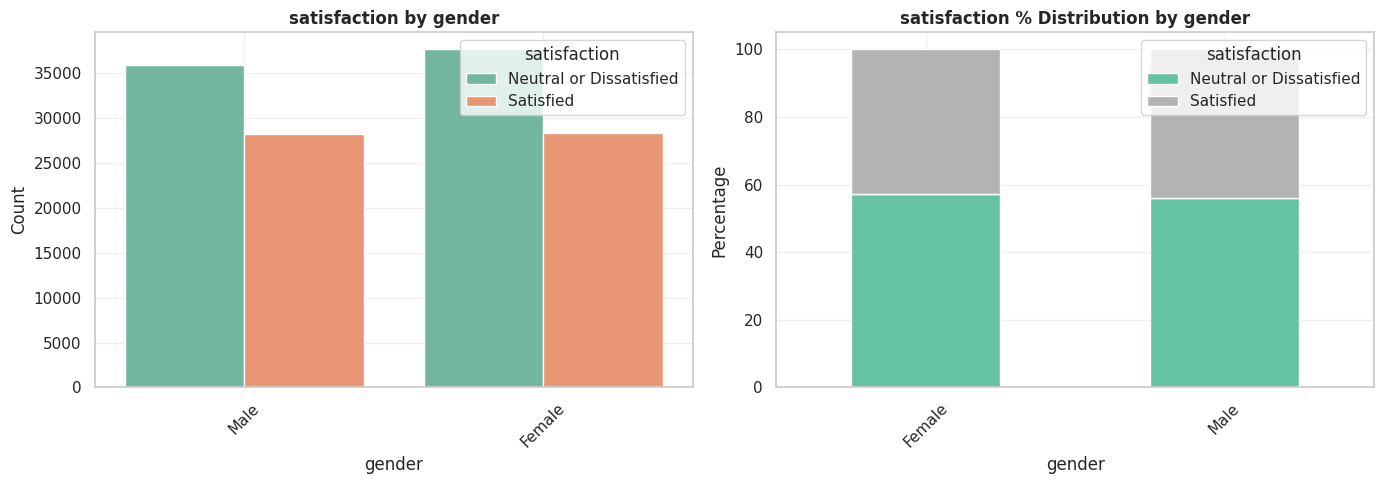


Analysis: customer_type vs satisfaction

Percentage Distribution:
satisfaction   Neutral or Dissatisfied  Satisfied
customer_type                                    
First-time                       76.03      23.97
Returning                        52.19      47.81


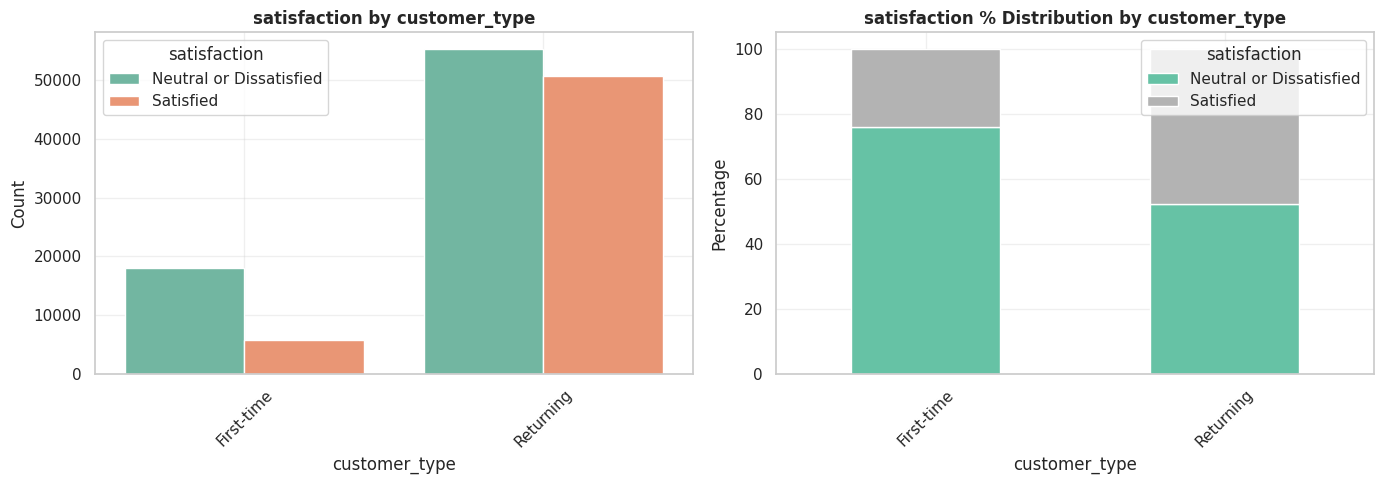


Analysis: type_of_travel vs satisfaction

Percentage Distribution:
satisfaction    Neutral or Dissatisfied  Satisfied
type_of_travel                                    
Business                          41.63      58.37
Personal                          89.87      10.13


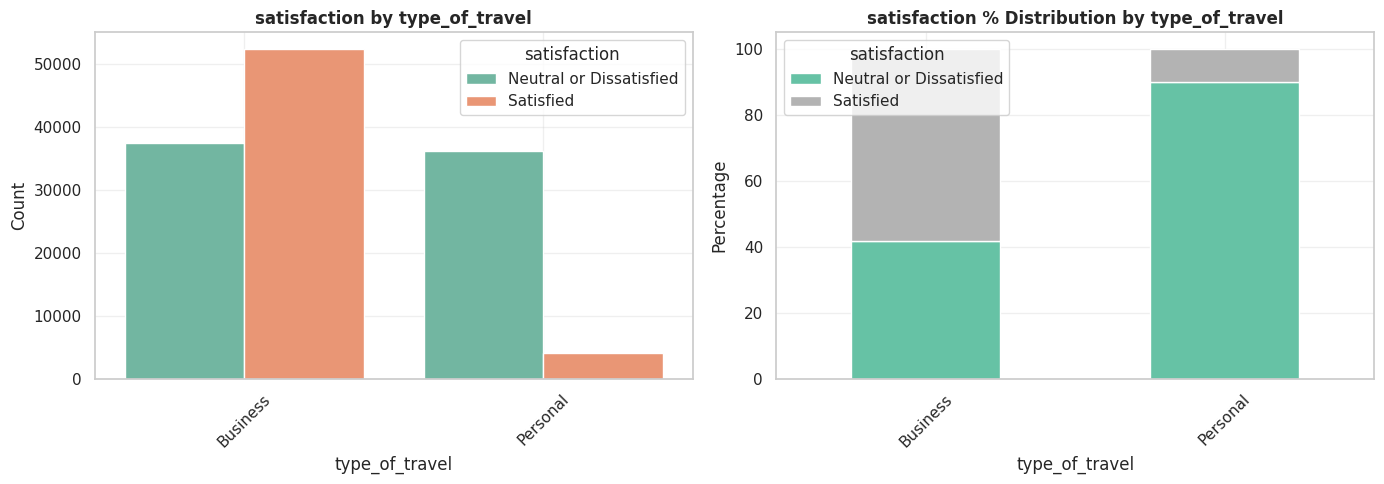

In [ ]:
print("BIVARIATE ANALYSIS - CATEGORICAL vs TARGET")

if 'satisfaction' in df_clean.columns:
    target_col = 'satisfaction'

    for cat_col in categorical_features[:3]:
        bivariate_categorical_vs_target(df_clean, cat_col, target_col)

# CELL 12: Correlation Analysis


CORRELATION ANALYSIS

[12.1] Computing Correlation Matrix...

[12.2] Correlation with Target (if numerical):

[12.3] Generating Correlation Heatmap...


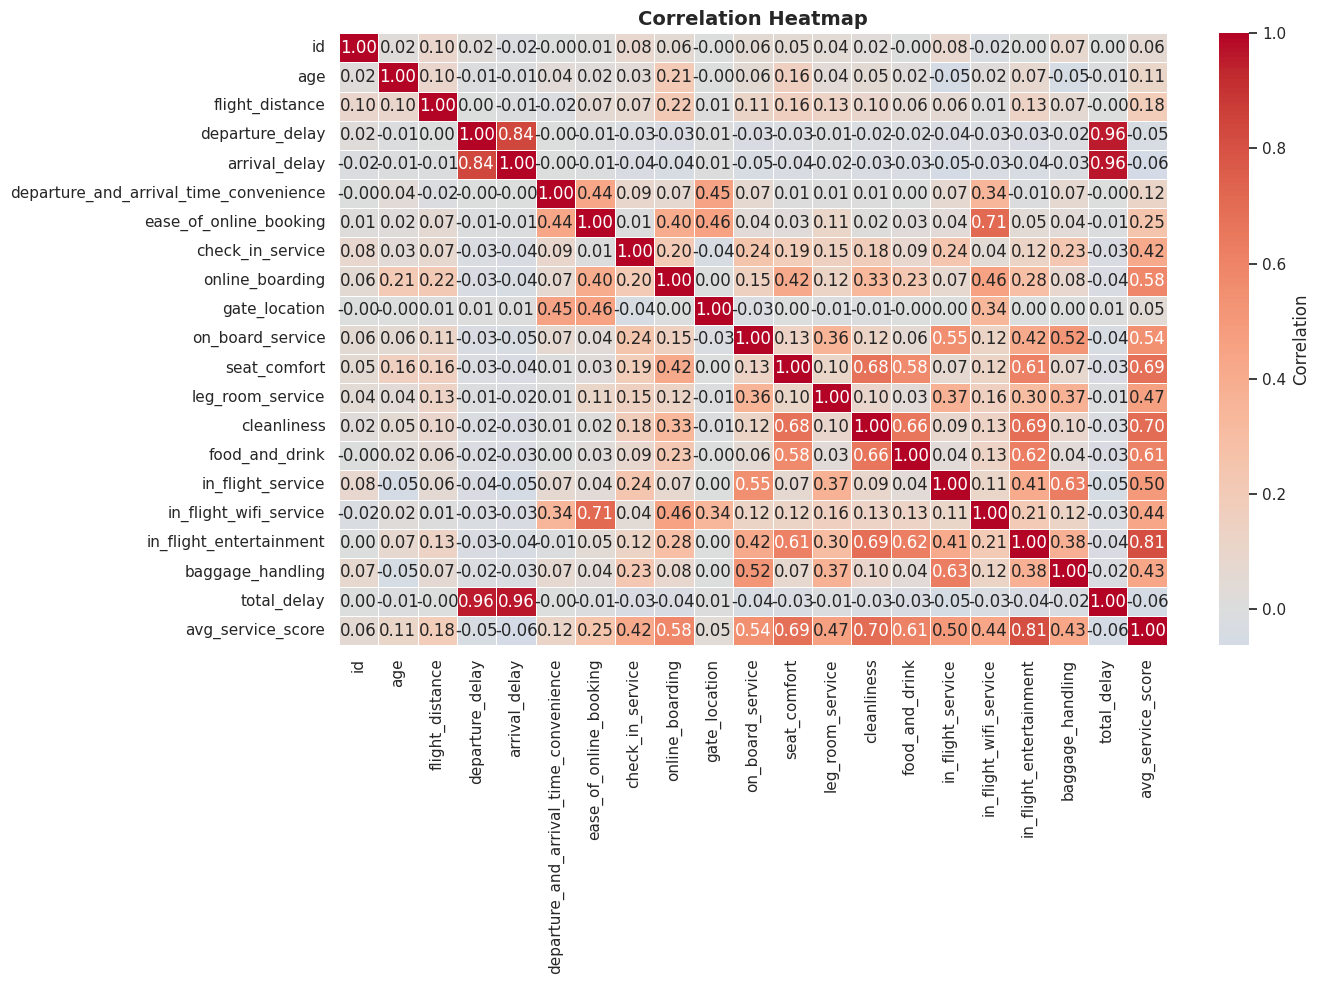

In [ ]:
print("CORRELATION ANALYSIS")

print("\n[12.1] Computing Correlation Matrix...")

numerical_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

print("\n[12.2] Correlation with Target (if numerical):")
if 'satisfaction' in corr_matrix.columns or any('satisfaction' in str(col).lower() for col in corr_matrix.columns):
    satisfaction_col = [col for col in corr_matrix.columns if 'satisfaction' in str(col).lower()]
    if satisfaction_col:
        target_corr = corr_matrix[satisfaction_col[0]].sort_values(ascending=False)
        print(target_corr.head(10))

print("\n[12.3] Generating Correlation Heatmap...")

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# CELL 13: Import Libraries

In [ ]:
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                            recall_score, classification_report, confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

# CELL 14: Prepare Features And Target

In [ ]:
print("MODEL PREPARATION")

# -----------------------------
# 14.1 Target encoding (force positive class = Satisfied)
# -----------------------------
if 'satisfaction' not in df_clean.columns:
    raise ValueError("Target column 'satisfaction' not found in df_clean.")

df_clean['satisfaction_encoded'] = (
    df_clean['satisfaction'].astype(str).str.strip().str.lower().eq('satisfied')
).astype(int)

target_col = 'satisfaction_encoded'
print("✓ Target encoded as: 1 = Satisfied, 0 = Not Satisfied")

# -----------------------------
# 14.2 Build feature frame (drop target text column)
# -----------------------------
df_model = df_clean.drop(columns=['satisfaction'], errors='ignore').copy()

# Ensure 'delay_category' is treated as object for one-hot encoding
if 'delay_category' in df_model.columns:
    df_model['delay_category'] = df_model['delay_category'].astype(object)

# Identify categorical columns (object type)
cat_cols = df_model.select_dtypes(include=['object']).columns.tolist()

# One-hot encode categorical features
if len(cat_cols) > 0:
    df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
    print(f"✓ One-hot encoded {len(cat_cols)} categorical columns")

# Prepare X and y
X = df_model.drop(columns=[target_col], errors='ignore')
y = df_model[target_col].copy()

# Ensure no weird ID column leaks if present
drop_like_id = [c for c in X.columns if 'id' in c.lower()]
if drop_like_id:
    X = X.drop(columns=drop_like_id)
    print(f"✓ Dropped ID-like columns: {drop_like_id}")

feature_cols = X.columns.tolist()

print(f"\n✓ Feature matrix shape: {X.shape}")
print(f"✓ Target vector shape: {y.shape}")
print("\nClass distribution:")
print(y.value_counts())


MODEL PREPARATION
✓ Target encoded as: 1 = Satisfied, 0 = Not Satisfied
✓ One-hot encoded 5 categorical columns
✓ Dropped ID-like columns: ['id']

✓ Feature matrix shape: (129880, 28)
✓ Target vector shape: (129880,)

Class distribution:
satisfaction_encoded
0    73452
1    56428
Name: count, dtype: int64


# CELL 15: Train-Test Split

In [ ]:
print("TRAIN-TEST SPLIT")

print("\n[15.1] Splitting Data (80-20 split on FULL dataset)...")

# Train-test split on FULL dataset (no sampling)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✓ Training set: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"✓ Test set: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")

print("\nClass distribution in training set:")
print(y_train.value_counts())


TRAIN-TEST SPLIT

[15.1] Splitting Data (80-20 split on FULL dataset)...
✓ Training set: 103,904 samples (80.0%)
✓ Test set: 25,976 samples (20.0%)

Class distribution in training set:
satisfaction_encoded
0    58762
1    45142
Name: count, dtype: int64


# CELL 16: Preprocessing

In [ ]:
print("PREPROCESSING")

print("\n[16.1] Applying Preprocessing...")

# Imputation
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("✓ Applied median imputation")
print("✓ Applied standard scaling")


PREPROCESSING

[16.1] Applying Preprocessing...
✓ Applied median imputation
✓ Applied standard scaling


# CELL 17: Handle Class Imbalance With SMOTE

In [ ]:
print("\n[17.1] Class Distribution BEFORE SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c:,} samples ({c/len(y_train)*100:.1f}%)")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"\n[17.2] Class Distribution AFTER SMOTE:")
unique, counts = np.unique(y_train_balanced, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c:,} samples ({c/len(y_train_balanced)*100:.1f}%)")

print(f"\n✓ Training set increased: {len(y_train):,} → {len(y_train_balanced):,}")


HANDLING CLASS IMBALANCE WITH SMOTE

[17.1] Class Distribution BEFORE SMOTE:
  Class 0: 58,762 samples (56.6%)
  Class 1: 45,142 samples (43.4%)

[17.2] Class Distribution AFTER SMOTE:
  Class 0: 58,762 samples (50.0%)
  Class 1: 58,762 samples (50.0%)

✓ Training set increased: 103,904 → 117,524


# CELL 18: Model Configuration

In [ ]:
models = {}

# 1. Logistic Regression
print("\n[18.1] Logistic Regression Configuration:")
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    solver='lbfgs',
    C=1.0
)
models['Logistic Regression'] = lr
print("  • Type: Linear Classifier")
print("  • max_iter: 1000")
print("  ✓ Simple, interpretable baseline")

# 2. Random Forest
print("\n[18.2] Random Forest Configuration:")
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_leaf=25,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
models['Random Forest'] = rf
print("  • Type: Bagging Ensemble")
print("  • n_estimators: 150")
print("  ✓ Reduces variance through bootstrap aggregation")

# 3. LightGBM
print("\n[18.4] LightGBM Configuration:")
lgbm = LGBMClassifier(
    n_estimators=250,
    learning_rate=0.008,
    max_depth=3,
    num_leaves=15,
    min_child_samples=80,
    subsample=0.5,
    subsample_freq=1,
    colsample_bytree=0.5,
    min_split_gain=0.05,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1,
    force_row_wise=True
)
models['LightGBM'] = lgbm
print("  • Type: Optimized Gradient Boosting")
print("  ✓ Leaf-wise growth, faster than XGBoost")

print(f"\n✓ Total models configured: {len(models)}")

# Model characteristics table
characteristics = pd.DataFrame({
    'Model': list(models.keys()),
    'Algorithm Type': ['Linear', 'Bagging', 'Gradient Boosting'],
    'Interpretability': ['High', 'Medium', 'Medium'],
    'Expected Speed': ['Fast', 'Medium', 'Very Fast'],
    'Handles Non-linearity': ['❌', '✓', '✓']
})

display(characteristics)


MODEL CONFIGURATION - DIVERSE ALGORITHM COMPARISON

[18.1] Logistic Regression Configuration:
  • Type: Linear Classifier
  • max_iter: 1000
  ✓ Simple, interpretable baseline

[18.2] Random Forest Configuration:
  • Type: Bagging Ensemble
  • n_estimators: 150
  ✓ Reduces variance through bootstrap aggregation

[18.4] LightGBM Configuration:
  • Type: Optimized Gradient Boosting
  ✓ Leaf-wise growth, faster than XGBoost

✓ Total models configured: 3


,Model,Algorithm Type,Interpretability,Expected Speed,Handles Non-linearity
0,Logistic Regression,Linear,High,Fast,❌
1,Random Forest,Bagging,Medium,Medium,✓
2,LightGBM,Gradient Boosting,Medium,Very Fast,✓


# CELL 19: Learning Curve

In [ ]:
from sklearn.model_selection import StratifiedKFold

def generate_learning_curve(model, X, y, name):
    """Generate learning curve with timing"""
    print(f"\n[{name}] Computing learning curve...")
    start_time = time.time()

    # Use StratifiedKFold for reproducible cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=cv,  # FIXED: Use StratifiedKFold instead of cv=5
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 12),
        n_jobs=-1
    )

    elapsed = time.time() - start_time

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    improvement = val_mean[-1] - val_mean[0]
    final_gap = train_mean[-1] - val_mean[-1]

    print(f"  Starting Validation: {val_mean[0]:.4f}")
    print(f"  Final Validation: {val_mean[-1]:.4f}")
    print(f"  Improvement: {improvement:+.4f}")
    print(f"  Train-Val Gap: {final_gap:.4f}")
    print(f"  ⏱️  Time taken: {elapsed:.1f}s")

    return {
        'train_sizes': train_sizes,
        'train_mean': train_mean,
        'train_std': train_std,
        'val_mean': val_mean,
        'val_std': val_std,
        'improvement': improvement,
        'final_gap': final_gap,
        'start_val': val_mean[0],
        'final_val': val_mean[-1],
        'time': elapsed
    }

# NOTE: Use 50% sample ONLY for learning curves (computational efficiency)
print("\n[Sampling 50% for Learning Curves - Computational Efficiency]")
X_lc_sample, _, y_lc_sample, _ = train_test_split(
    X_train_balanced, y_train_balanced,
    train_size=0.5,
    random_state=42,
    stratify=y_train_balanced
)

results = {}
for name, model in models.items():
    results[name] = generate_learning_curve(model, X_lc_sample, y_lc_sample, name)


LEARNING CURVE ANALYSIS

[Sampling 50% for Learning Curves - Computational Efficiency]

[Logistic Regression] Computing learning curve...
  Starting Validation: 0.8690
  Final Validation: 0.8684
  Improvement: -0.0006
  Train-Val Gap: 0.0003
  ⏱️  Time taken: 5.6s

[Random Forest] Computing learning curve...
  Starting Validation: 0.9085
  Final Validation: 0.9348
  Improvement: +0.0262
  Train-Val Gap: 0.0014
  ⏱️  Time taken: 167.6s

[LightGBM] Computing learning curve...
  Starting Validation: 0.9029
  Final Validation: 0.9211
  Improvement: +0.0182
  Train-Val Gap: 0.0002
  ⏱️  Time taken: 61.7s


# CELL 20: Visualize Learning Curve


LEARNING CURVE VISUALIZATION


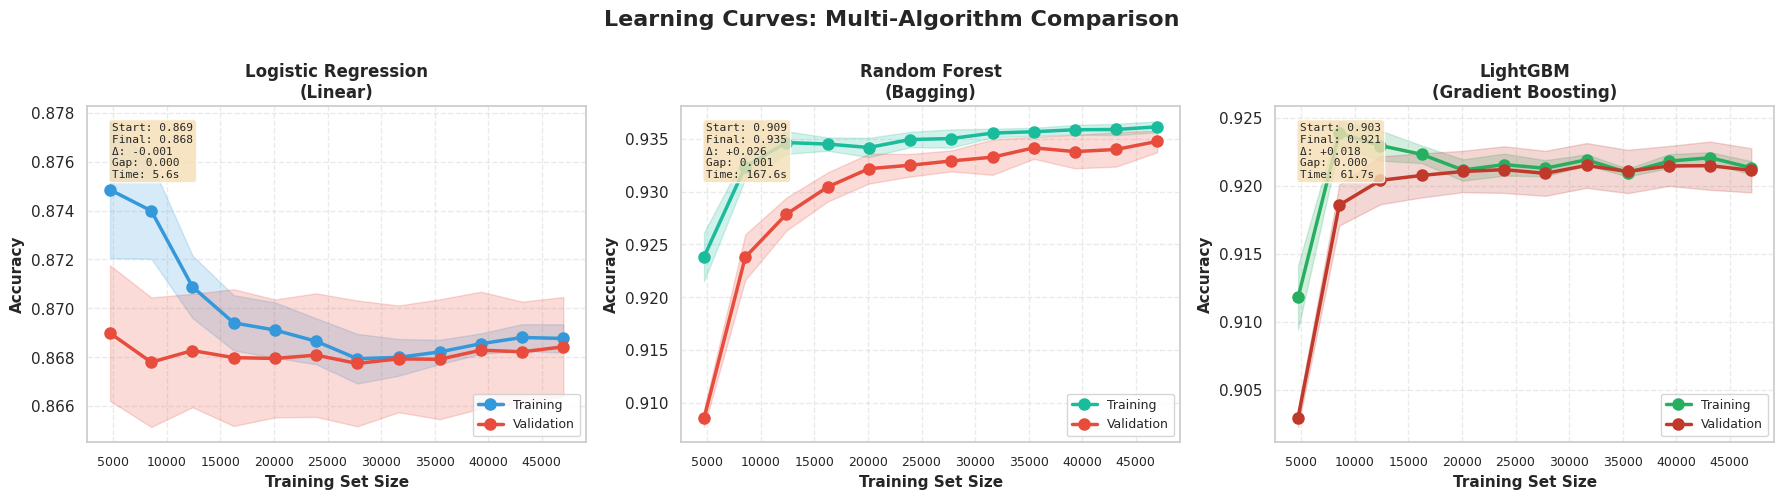

,Model,Start Val,Final Val,Improvement,Train-Val Gap,Time (s)
0,Logistic Regression,0.8690,0.8684,-0.0006,0.0003,5.6
1,Random Forest,0.9085,0.9348,+0.0262,0.0014,167.6
2,LightGBM,0.9029,0.9211,+0.0182,0.0002,61.7


In [ ]:
n_models = len(results)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten() if n_models > 1 else [axes]

colors = {
    'Logistic Regression': ('#3498db', '#e74c3c'),
    'Random Forest': ('#1abc9c', '#e74c3c'),
    'LightGBM': ('#27ae60', '#c0392b')
}

for idx, (name, data) in enumerate(results.items()):
    ax = axes[idx]

    train_color, val_color = colors.get(name, ('#3498db', '#e74c3c'))

    # Training curve
    ax.plot(data['train_sizes'], data['train_mean'], 'o-',
            color=train_color, label='Training', linewidth=2.5, markersize=8)
    ax.fill_between(data['train_sizes'],
                    data['train_mean'] - data['train_std'],
                    data['train_mean'] + data['train_std'],
                    alpha=0.2, color=train_color)

    # Validation curve
    ax.plot(data['train_sizes'], data['val_mean'], 'o-',
            color=val_color, label='Validation', linewidth=2.5, markersize=8)
    ax.fill_between(data['train_sizes'],
                    data['val_mean'] - data['val_std'],
                    data['val_mean'] + data['val_std'],
                    alpha=0.2, color=val_color)

    ax.set_xlabel('Training Set Size', fontsize=11, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax.set_title(f'{name}\n({characteristics[characteristics["Model"]==name]["Algorithm Type"].values[0] if name in characteristics["Model"].values else ""})',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.4, linestyle='--')

    # X-axis ticks
    max_size = int(data['train_sizes'].max())
    tick_positions = np.arange(5000, max_size + 1, 5000)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([f'{int(x)}' for x in tick_positions], fontsize=9)

    # Metrics box
    textstr = f'Start: {data["start_val"]:.3f}\nFinal: {data["final_val"]:.3f}\nΔ: {data["improvement"]:+.3f}\nGap: {data["final_gap"]:.3f}\nTime: {data["time"]:.1f}s'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', bbox=props, family='monospace')

# Hide empty subplots
for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Learning Curves: Multi-Algorithm Comparison',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('learning_curves_multi_algorithm.png', dpi=300, bbox_inches='tight')
plt.show()

# Learning curve summary
lc_summary = pd.DataFrame([
    {
        'Model': name,
        'Start Val': f"{data['start_val']:.4f}",
        'Final Val': f"{data['final_val']:.4f}",
        'Improvement': f"{data['improvement']:+.4f}",
        'Train-Val Gap': f"{data['final_gap']:.4f}",
        'Time (s)': f"{data['time']:.1f}"
    }
    for name, data in results.items()
])

display(lc_summary)

# CELL 21: Model Training

In [ ]:

trained_models = {}
training_times = {}

for name, model in models.items():
    print(f"\n[Training {name}]...")
    start = time.time()
    model.fit(X_train_balanced, y_train_balanced)
    elapsed = time.time() - start

    trained_models[name] = model
    training_times[name] = elapsed
    print(f"  ✓ Completed in {elapsed:.2f}s")


MODEL TRAINING

[Training Logistic Regression]...
  ✓ Completed in 1.18s

[Training Random Forest]...
  ✓ Completed in 11.33s

[Training LightGBM]...
  ✓ Completed in 3.71s


# CELL 22: Model Evaluation

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

evaluation_results = []

for name, model in trained_models.items():
    print(f"\n{'='*60}")
    print(f"{name} - Performance Metrics")
    print('='*60)

    # Predictions
    start = time.time()
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]  # Probability for positive class
    pred_time = time.time() - start

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # NEW: ROC-AUC and PR-AUC
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")  # NEW
    print(f"PR-AUC:    {pr_auc:.4f}")   # NEW
    print(f"Prediction Time: {pred_time:.4f}s")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    evaluation_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,      # NEW
        'PR-AUC': pr_auc,        # NEW
        'Training Time (s)': training_times[name],
        'Prediction Time (s)': pred_time,
        'predictions': y_pred
    })


MODEL EVALUATION

Logistic Regression - Performance Metrics
Accuracy:  0.8721
Precision: 0.8725
Recall:    0.8721
F1-Score:  0.8722
ROC-AUC:   0.9305
PR-AUC:    0.9331
Prediction Time: 0.0035s

Classification Report:
              precision    recall  f1-score   support

           0     0.8925    0.8798    0.8861     14690
           1     0.8464    0.8621    0.8542     11286

    accuracy                         0.8721     25976
   macro avg     0.8695    0.8710    0.8701     25976
weighted avg     0.8725    0.8721    0.8722     25976


Random Forest - Performance Metrics
Accuracy:  0.9350
Precision: 0.9349
Recall:    0.9350
F1-Score:  0.9350
ROC-AUC:   0.9849
PR-AUC:    0.9826
Prediction Time: 0.4053s

Classification Report:
              precision    recall  f1-score   support

           0     0.9407    0.9445    0.9426     14690
           1     0.9274    0.9226    0.9250     11286

    accuracy                         0.9350     25976
   macro avg     0.9341    0.9335    0.9338

# CELL 23: Model Comparison

In [ ]:
print("COMPREHENSIVE MODEL COMPARISON")

comparison_df = pd.DataFrame([
    {k: v for k, v in result.items() if k != 'predictions'}
    for result in evaluation_results
])

# Sort by F1-Score
comparison_df = comparison_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
display(comparison_df)

# Ranking table
print("\n" + "=" * 80)
print("MODEL RANKINGS")
print('=' * 80)

rankings = pd.DataFrame({
    'Model': comparison_df['Model'],
    'Accuracy Rank': comparison_df['Accuracy'].rank(ascending=False).astype(int),
    'F1-Score Rank': comparison_df['F1-Score'].rank(ascending=False).astype(int),
    'Speed Rank': comparison_df['Training Time (s)'].rank(ascending=True).astype(int),
    'Overall Score': (
        comparison_df['Accuracy'].rank(ascending=False) +
        comparison_df['F1-Score'].rank(ascending=False) +
        comparison_df['Training Time (s)'].rank(ascending=True)
    ) / 3
})

rankings = rankings.sort_values('Overall Score').reset_index(drop=True)
rankings['Final Rank'] = range(1, len(rankings) + 1)

display(rankings[['Final Rank', 'Model', 'Accuracy Rank', 'F1-Score Rank', 'Speed Rank', 'Overall Score']])


COMPREHENSIVE MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Training Time (s),Prediction Time (s)
0,Random Forest,0.934978,0.934948,0.934978,0.934958,0.984900,0.982606,11.332419,0.405282
1,LightGBM,0.919503,0.919494,0.919503,0.919498,0.973876,0.968804,3.712108,0.375337
2,Logistic Regression,0.872113,0.872486,0.872113,0.872242,0.930460,0.933077,1.182339,0.003543



MODEL RANKINGS


,Final Rank,Model,Accuracy Rank,F1-Score Rank,Speed Rank,Overall Score
0,1,Random Forest,1,1,3,1.666667
1,2,LightGBM,2,2,2,2.000000
2,3,Logistic Regression,3,3,1,2.333333


# CELL 24: Confusion Matrices


CONFUSION MATRICES


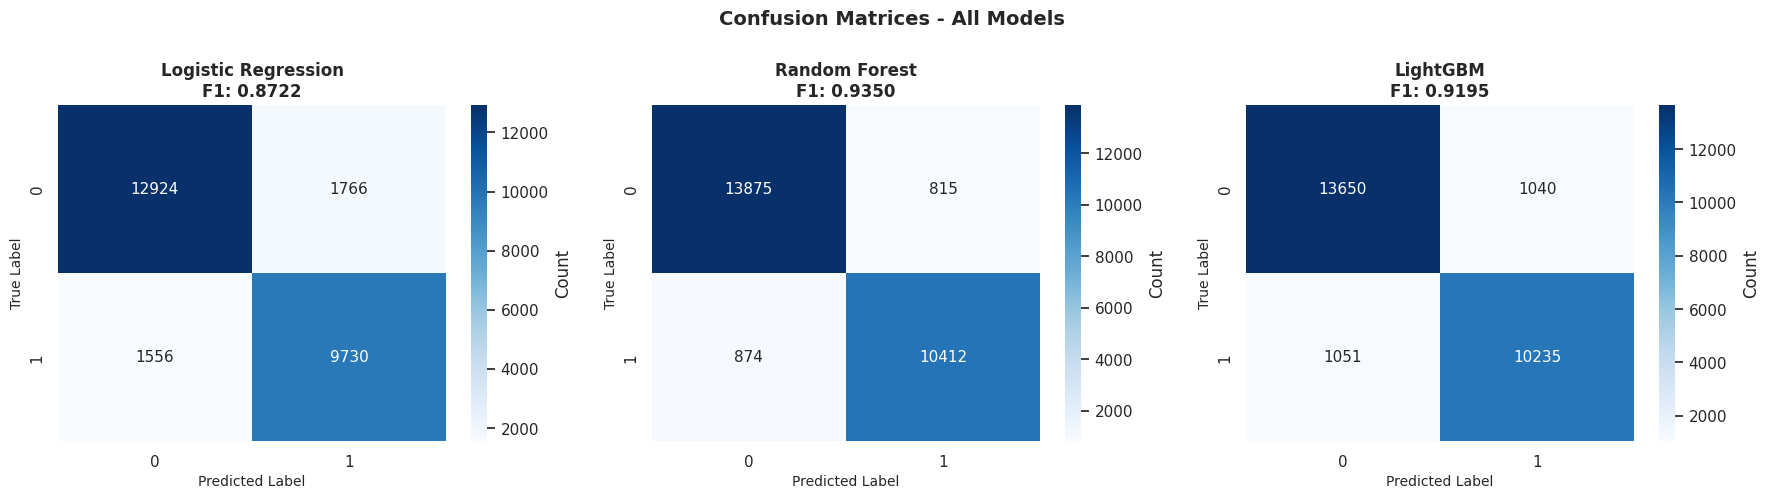

In [ ]:
print("CONFUSION MATRICES")

n_models = len(evaluation_results)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten() if n_models > 1 else [axes]

for idx, result in enumerate(evaluation_results):
    ax = axes[idx]
    cm = confusion_matrix(y_test, result['predictions'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                cbar_kws={'label': 'Count'}, annot_kws={'size': 11})

    ax.set_title(f'{result["Model"]}\nF1: {result["F1-Score"]:.4f}',
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

# Hide empty subplots
for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# CELL 25: Performance Metrics Visualization


PERFORMANCE METRICS VISUALIZATION


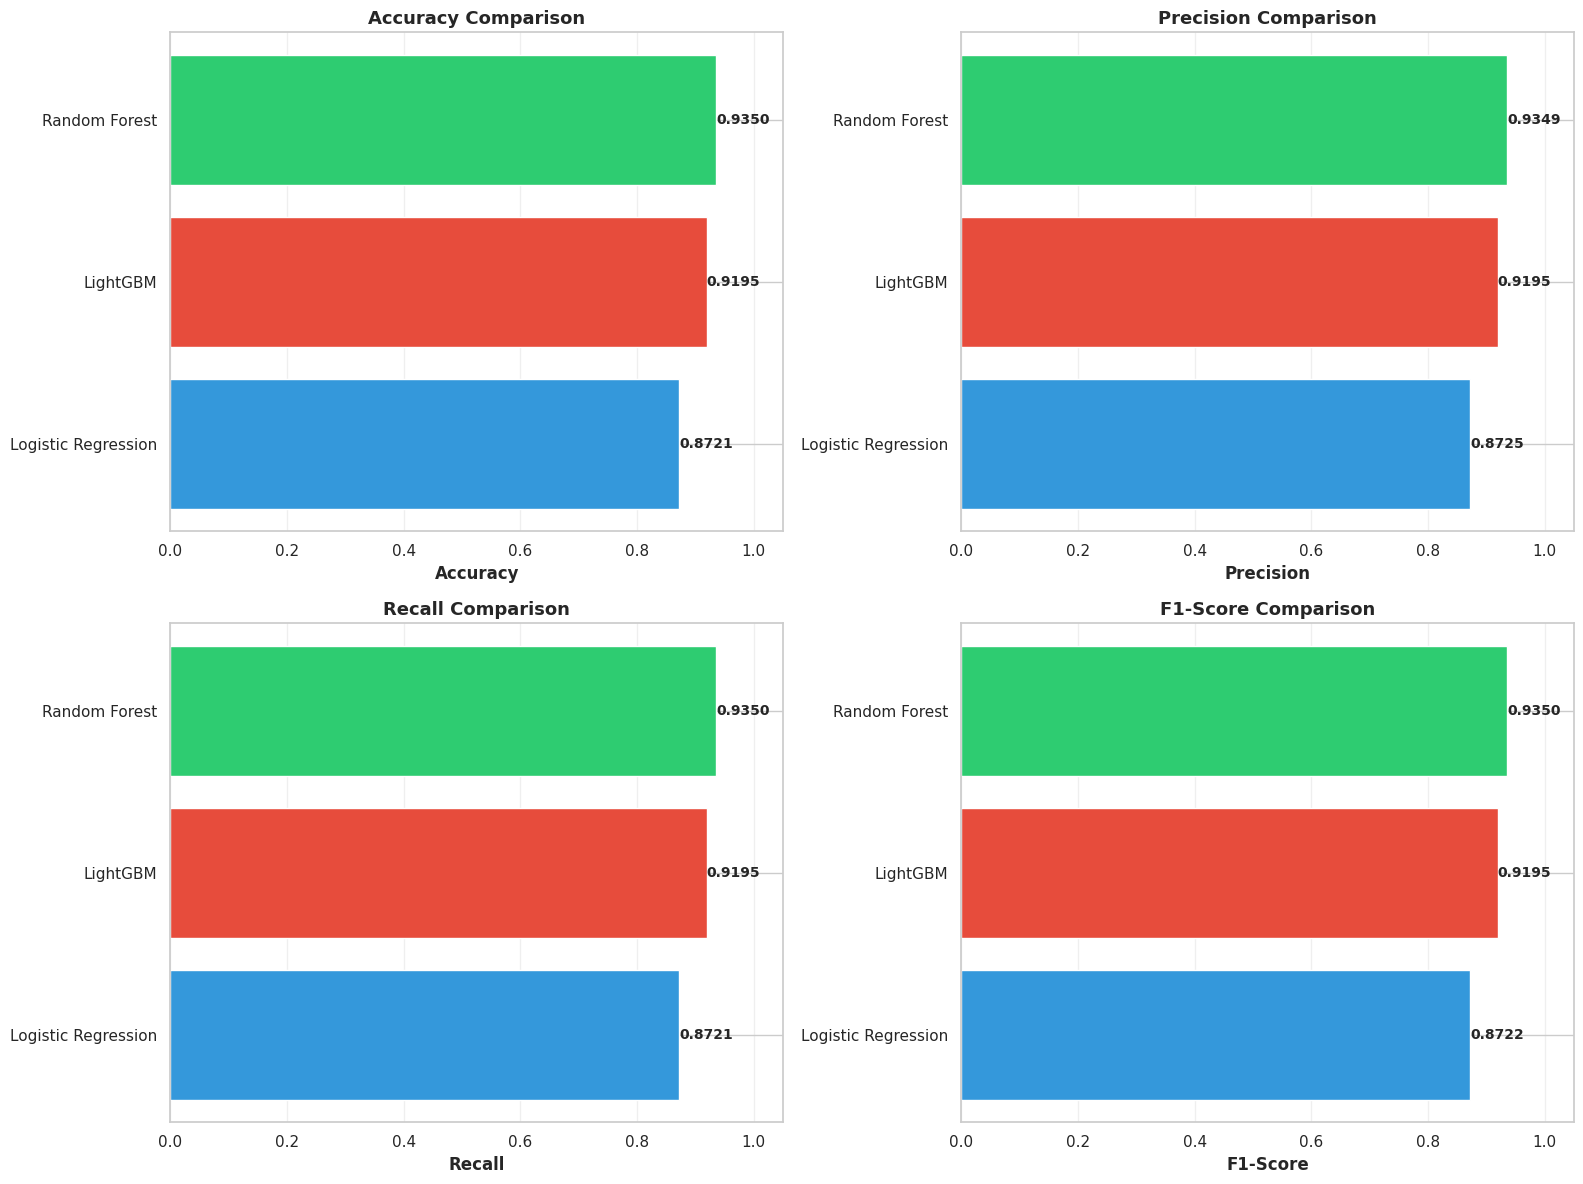

In [ ]:
print("PERFORMANCE METRICS VISUALIZATION")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]

    data = comparison_df.sort_values(metric, ascending=True)
    bars = ax.barh(data['Model'], data[metric], color=colors_palette[:len(data)])

    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2,
                f'{width:.4f}',
                ha='left', va='center', fontsize=10, fontweight='bold')

    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, 1.05)

plt.tight_layout()
plt.savefig('performance_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# CELL 26: Feature Importance Analysis


FEATURE IMPORTANCE ANALYSIS

[Random Forest] Top 10 Features:
online_boarding            0.205904
in_flight_wifi_service     0.141182
type_of_travel_Personal    0.135013
avg_service_score          0.106041
class_Economy              0.091656
in_flight_entertainment    0.054856
ease_of_online_booking     0.044015
seat_comfort               0.034447
leg_room_service           0.031477
customer_type_Returning    0.030626
dtype: float64

[LightGBM] Top 10 Features:
in_flight_wifi_service     403
online_boarding            220
type_of_travel_Personal    173
avg_service_score          134
ease_of_online_booking     130
class_Economy              102
customer_type_Returning     73
leg_room_service            71
in_flight_entertainment     68
flight_distance             37
dtype: int32


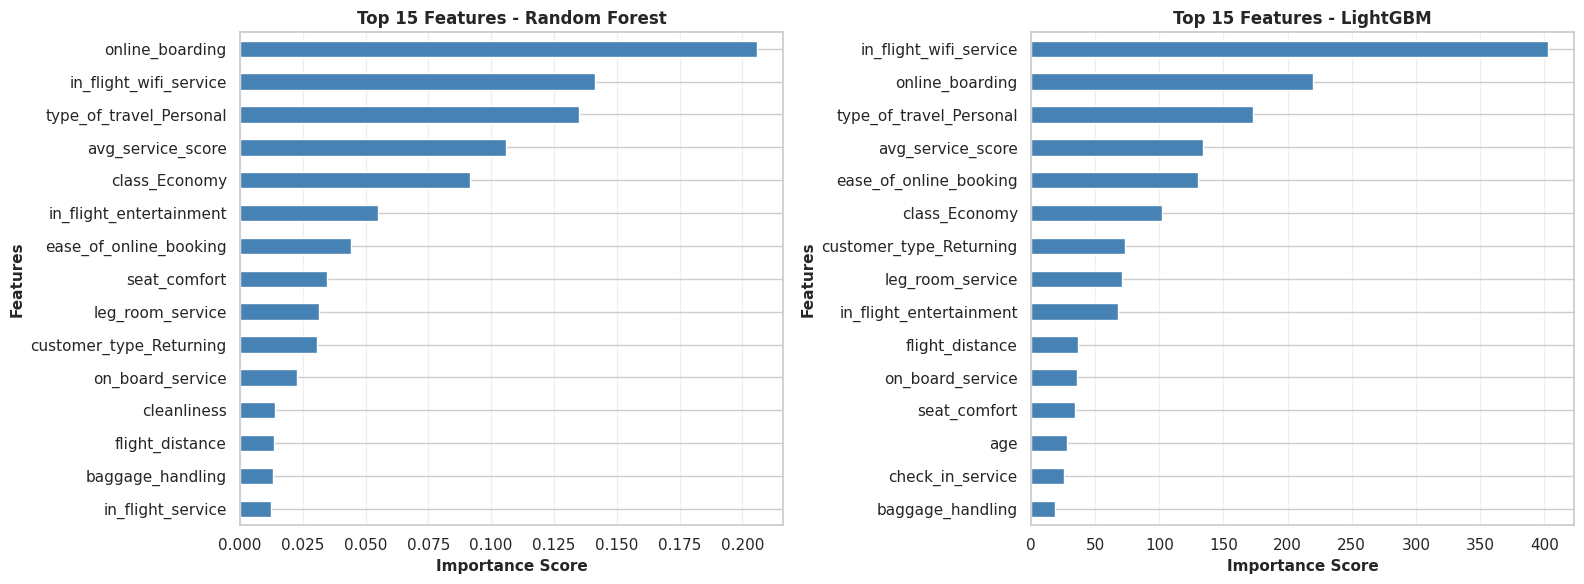

In [ ]:
print("FEATURE IMPORTANCE ANALYSIS")

tree_models = ['Random Forest', 'LightGBM']
available_tree_models = [m for m in tree_models if m in trained_models]

if available_tree_models:
    fig, axes = plt.subplots(1, len(available_tree_models),
                            figsize=(8*len(available_tree_models), 6))

    if len(available_tree_models) == 1:
        axes = [axes]

    for idx, model_name in enumerate(available_tree_models):
        ax = axes[idx]

        model = trained_models[model_name]
        importance = pd.Series(
            model.feature_importances_,
            index=feature_cols
        ).sort_values(ascending=False)

        print(f"\n[{model_name}] Top 10 Features:")
        print(importance.head(10))

        importance.head(15).sort_values().plot(kind='barh', ax=ax, color='steelblue')
        ax.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
        ax.set_ylabel('Features', fontsize=11, fontweight='bold')
        ax.set_title(f'Top 15 Features - {model_name}', fontsize=12, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# Cell 27: Loss Curve


GENERATING LOSS CURVES (LOG LOSS)

[Processing Random Forest]...

[Processing LightGBM]...


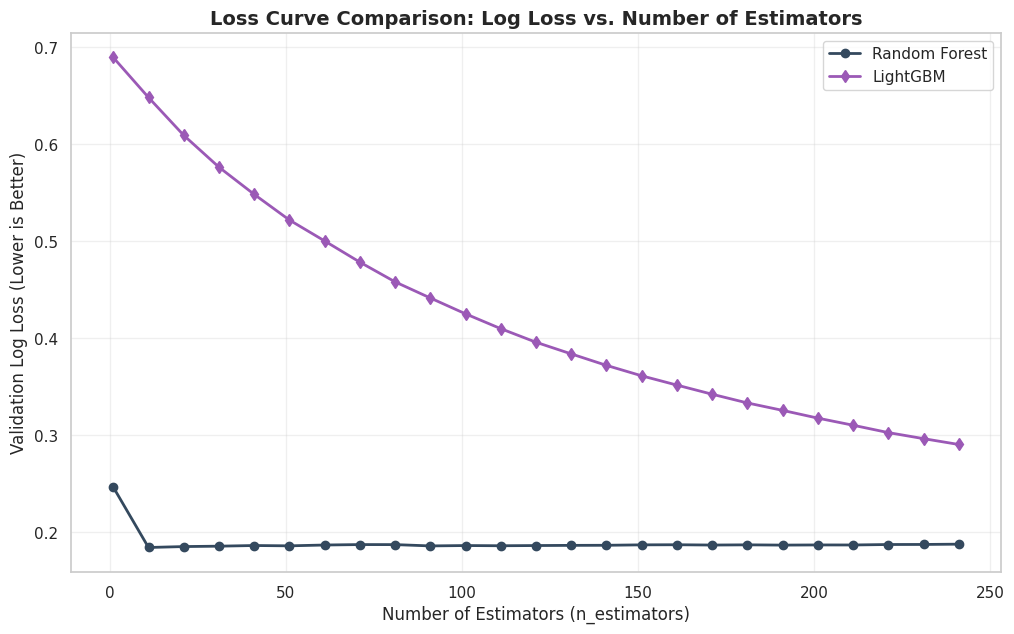


✓ Loss curve generation complete.


In [ ]:
from sklearn.metrics import log_loss
from lightgbm import LGBMClassifier # Ensure LGBMClassifier is imported
from sklearn.ensemble import RandomForestClassifier # Ensure RandomForestClassifier is imported

# 1. Configuration for the loss curve
tree_range = range(1, 251, 10)  # Testing from 1 to 250 trees
loss_results = {
    'Random Forest': [],
    'LightGBM': []
}

print("\n" + "=" * 80)
print("GENERATING LOSS CURVES (LOG LOSS)")
print("=" * 80)

# 2. Iterate through relevant model types from the 'models' dictionary
#    Only tree-based ensembles support n_estimators
for model_name, model_obj in models.items():
    if isinstance(model_obj, (RandomForestClassifier, LGBMClassifier)):
        print(f"\n[Processing {model_name}]...")
        # Create a fresh instance of the model to avoid issues with already fitted models
        # and to ensure n_estimators can be set iteratively.
        if isinstance(model_obj, RandomForestClassifier):
            current_model = RandomForestClassifier(
                max_depth=model_obj.max_depth,
                min_samples_leaf=model_obj.min_samples_leaf,
                max_features=model_obj.max_features,
                random_state=model_obj.random_state,
                n_jobs=model_obj.n_jobs
            )
        elif isinstance(model_obj, LGBMClassifier):
            current_model = LGBMClassifier(
                learning_rate=model_obj.learning_rate,
                max_depth=model_obj.max_depth,
                num_leaves=model_obj.num_leaves,
                min_child_samples=model_obj.min_child_samples,
                subsample=model_obj.subsample,
                subsample_freq=model_obj.subsample_freq,
                colsample_bytree=model_obj.colsample_bytree,
                min_split_gain=model_obj.min_split_gain,
                reg_alpha=model_obj.reg_alpha,
                reg_lambda=model_obj.reg_lambda,
                random_state=model_obj.random_state,
                verbose=-1, # Suppress verbose output for clean execution
                force_row_wise=model_obj.force_row_wise
            )
        else:
            continue # Skip other model types if any

        # 3. Training and recording loss
        model_losses = []
        for n in tree_range:
            # Suppress specific LightGBM warnings during iterative fitting
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", UserWarning)
                current_model.set_params(n_estimators=n)
                current_model.fit(X_train_balanced, y_train_balanced)
                # log_loss requires probabilities, not direct predictions
                model_losses.append(log_loss(y_test, current_model.predict_proba(X_test_scaled)))
        loss_results[model_name] = model_losses

# 4. Visualization
plt.figure(figsize=(12, 7))

for model_name, losses in loss_results.items():
    if model_name == 'Random Forest':
        plt.plot(tree_range, losses, 'o-', label='Random Forest', color='#34495e', linewidth=2)
    elif model_name == 'LightGBM':
        plt.plot(tree_range, losses, 'd-', label='LightGBM', color='#9b59b6', linewidth=2)

plt.title('Loss Curve Comparison: Log Loss vs. Number of Estimators', fontsize=14, fontweight='bold')
plt.xlabel('Number of Estimators (n_estimators)', fontsize=12)
plt.ylabel('Validation Log Loss (Lower is Better)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print("\n✓ Loss curve generation complete.")

# CELL 29: Permutation Importance



PERMUTATION IMPORTANCE ANALYSIS

[Logistic Regression] Computing permutation importance...
  ✓ Completed in 3.1s

  Top 5 Critical Features:
    type_of_travel_Personal        0.1200 ± 0.0028
    customer_type_Returning        0.0474 ± 0.0015
    online_boarding                0.0353 ± 0.0009
    in_flight_wifi_service         0.0189 ± 0.0015
    avg_service_score              0.0116 ± 0.0008

[Random Forest] Computing permutation importance...
  ✓ Completed in 56.9s

  Top 5 Critical Features:
    type_of_travel_Personal        0.1029 ± 0.0019
    in_flight_wifi_service         0.0515 ± 0.0012
    online_boarding                0.0258 ± 0.0011
    class_Economy                  0.0095 ± 0.0005
    customer_type_Returning        0.0089 ± 0.0003

[LightGBM] Computing permutation importance...
  ✓ Completed in 45.8s

  Top 5 Critical Features:
    in_flight_wifi_service         0.0971 ± 0.0022
    type_of_travel_Personal        0.0906 ± 0.0019
    online_boarding                0.0371 ±

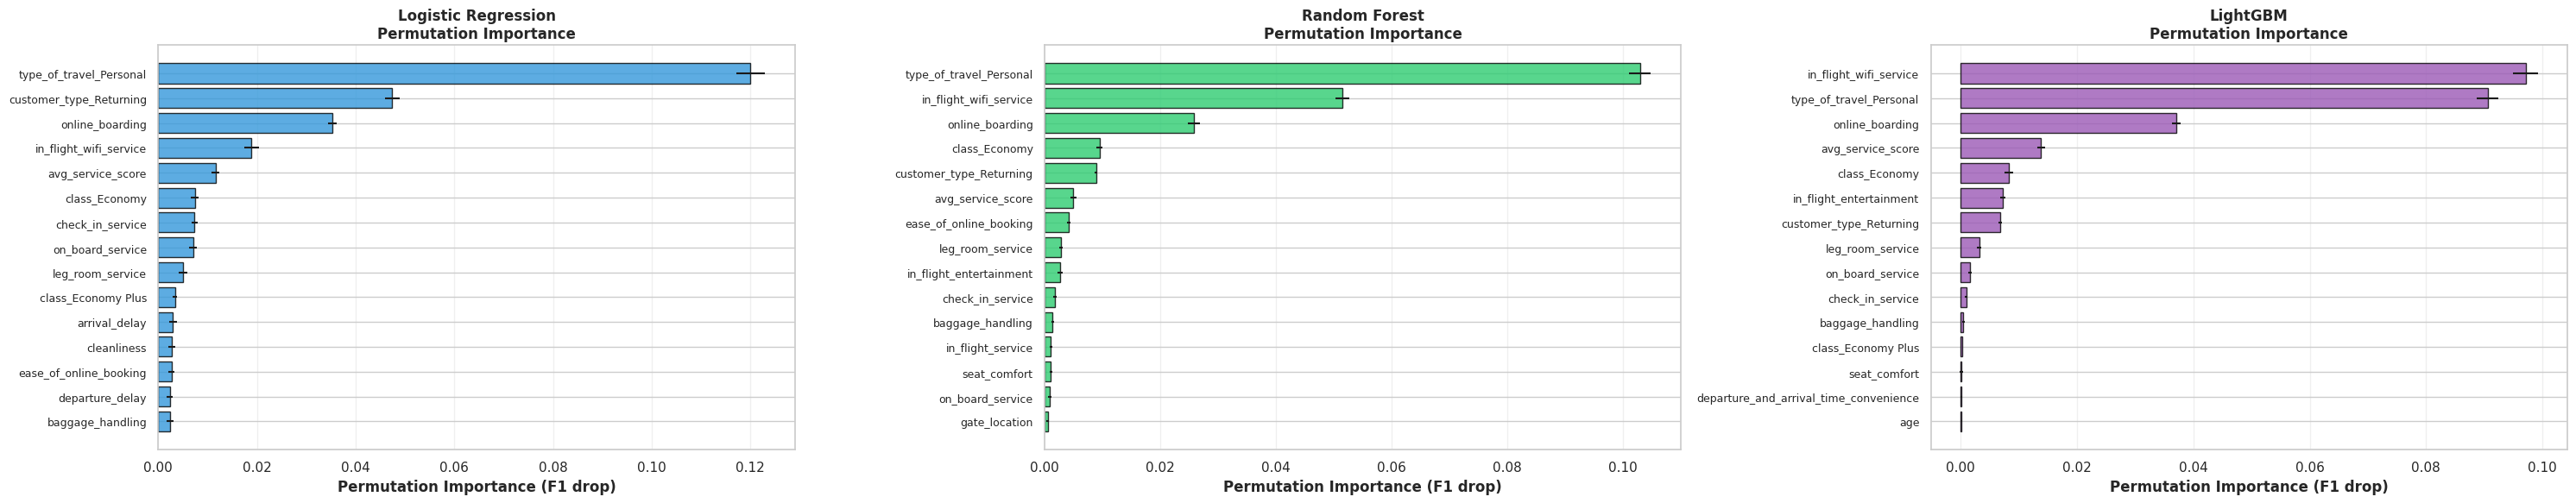

In [ ]:
print("PERMUTATION IMPORTANCE ANALYSIS")

from sklearn.inspection import permutation_importance

perm_results = {}

for name, model in trained_models.items():
    print(f"\n[{name}] Computing permutation importance...")
    start = time.time()

    perm_imp = permutation_importance(
        model, X_test_scaled, y_test,
        n_repeats=10,
        random_state=42,
        n_jobs=-1,
        scoring='f1_weighted'
    )

    elapsed = time.time() - start

    perm_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': perm_imp.importances_mean,
        'Std': perm_imp.importances_std
    }).sort_values('Importance', ascending=False)

    perm_results[name] = perm_df

    print(f"  ✓ Completed in {elapsed:.1f}s")
    print(f"\n  Top 5 Critical Features:")
    for idx, row in perm_df.head(5).iterrows():
        print(f"    {row['Feature']:30s} {row['Importance']:.4f} ± {row['Std']:.4f}")

# Visualize permutation importance
n_models = len(perm_results)
fig, axes = plt.subplots(1, n_models, figsize=(10*n_models, 6))

if n_models == 1:
    axes = [axes]

colors_map = {
    'Logistic Regression': '#3498db',
    'Random Forest': '#2ecc71',
    'LightGBM': '#9b59b6'
}

for idx, (name, perm_df) in enumerate(perm_results.items()):
    ax = axes[idx]

    top15 = perm_df.head(15).sort_values('Importance')
    color = colors_map.get(name, '#34495e')

    ax.barh(range(len(top15)), top15['Importance'],
            xerr=top15['Std'], color=color, edgecolor='black', alpha=0.8)
    ax.set_yticks(range(len(top15)))
    ax.set_yticklabels(top15['Feature'], fontsize=9)
    ax.set_xlabel('Permutation Importance (F1 drop)', fontweight='bold')
    ax.set_title(f'{name}\nPermutation Importance', fontweight='bold', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()